# Generate the Gabor library

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from wavelet_utils import makeGaborFilter_visual, make_and_save_FilterLibrary, makeFilterParamDict, loadFilterParamDict
import json

## Parameters

In [19]:
visual_coverage = [-90, 0, -30, 30] # [az_left, az_right, el_bottom, el_top] screen coverage in visual degrees
screen_x = 100 # horizontal screen size in pixels for the Gabor filter generation and movie analysis

nx = 4 # number of Gabor filters in the horizontal direction (azimuth) (y will be generated)

n_thetas = 8 # number of angles to generate

size_min = 3 # minimum size in visual degrees
size_max = 14 # maximum size in visual degrees
n_sizes = 5   # number of sizes to generate

freq_min = .02 # minimum frequency in cycles per visual degree
freq_max = .1 # maximum frequency in cycles per visual degree
n_freqs = 4  # number of frequencies to generate

phase_min = 0  # minimum phase in radians
phase_max = 2 * np.pi # maximum phase in radians
n_phases = 5  # number of phases to generate


In [20]:
#calculations
az_left, az_right, el_bottom, el_top = visual_coverage

screen_y = int(screen_x * (el_top - el_bottom) / (az_right - az_left))
ny = int(nx * (el_top - el_bottom) / (az_right - az_left))

# centers in visual degrees
x_steps = np.linspace(az_left, az_right, nx, endpoint=False)+(az_right - az_left) / (2*nx)
y_steps = np.linspace(el_bottom, el_top, ny, endpoint=False)+(el_top - el_bottom) / (2*ny)

angles= np.linspace(0, np.pi, n_thetas, endpoint=False)
sizes = np.logspace(np.log10(size_min), np.log10(size_max), n_sizes)
freqs = np.logspace(np.log10(freq_min), np.log10(freq_max), n_freqs)
phases = np.linspace(phase_min, phase_max, n_phases)

print(f"Screen size: {screen_x}x{screen_y} pixels")
print(f"Visual coverage: {visual_coverage} degrees")
print(f"Center positions (x_deg): {np.round(x_steps, 1)} degrees")
print(f"Center positions (y_deg): {np.round(y_steps, 1)} degrees")
print(f"Angles (degrees): {np.round(np.rad2deg(angles), 1)}")
print(f"Sizes (degrees): {sizes}")
print(f"Frequencies (cycles/degree): {freqs}")
print(f"Phases (radians): {phases}")


Screen size: 100x66 pixels
Visual coverage: [-90, 0, -30, 30] degrees
Center positions (x_deg): [-78.8 -56.2 -33.8 -11.2] degrees
Center positions (y_deg): [-15.  15.] degrees
Angles (degrees): [  0.   22.5  45.   67.5  90.  112.5 135.  157.5]
Sizes (degrees): [ 3.          4.40933352  6.4807407   9.52524907 14.        ]
Frequencies (cycles/degree): [0.02       0.03419952 0.05848035 0.1       ]
Phases (radians): [0.         1.57079633 3.14159265 4.71238898 6.28318531]


In [21]:
total_n=len(sizes)*len(angles)*len(freqs)*len(phases)*len(x_steps)*len(y_steps)
print(f"Total number of Gabor filters to generate: {total_n}")

Total number of Gabor filters to generate: 6400


In [22]:
# a control
gabor_step=(az_right-az_left)/nx
print(f"Control: Gabor step in visual degrees (x): {gabor_step:.1f}, vs size_min: {size_min:.1f} degrees")
gabor_step=(el_top-el_bottom)/ny
print(f"Control: Gabor step in visual degrees (y): {gabor_step:.1f}, vs size_min: {size_min:.1f} degrees")


Control: Gabor step in visual degrees (x): 22.5, vs size_min: 3.0 degrees
Control: Gabor step in visual degrees (y): 30.0, vs size_min: 3.0 degrees


## Do the generation

In [23]:

path = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'

# pack parameters into a dictionary 
params=makeFilterParamDict(screen_x, screen_y, visual_coverage, x_steps, y_steps, angles, sizes, freqs, phases)

# generate and save the filter library if it doesn't exist
lib_path, sidecar_path = make_and_save_FilterLibrary(path, params)

Library file already exists. Skipping generation.


## Testing: loading and displaying the library

In [ ]:
library = np.load(lib_path)
print(f"Loaded Gabor filter library from {lib_path} with shape {library.shape}")

# load the parameters from the sidecar JSON file
xs, ys, angles, sizes, freqs, phases, visual_coverage, screen_x, screen_y = loadFilterParamDict(sidecar_path)

Loaded Gabor filter library from D:\SynologyDriveSyncedDATA\PROCESSED\Waven\gaborLibrary_4_2_8_5_4_5.npy with shape (4, 2, 8, 5, 4, 5, 100, 66)


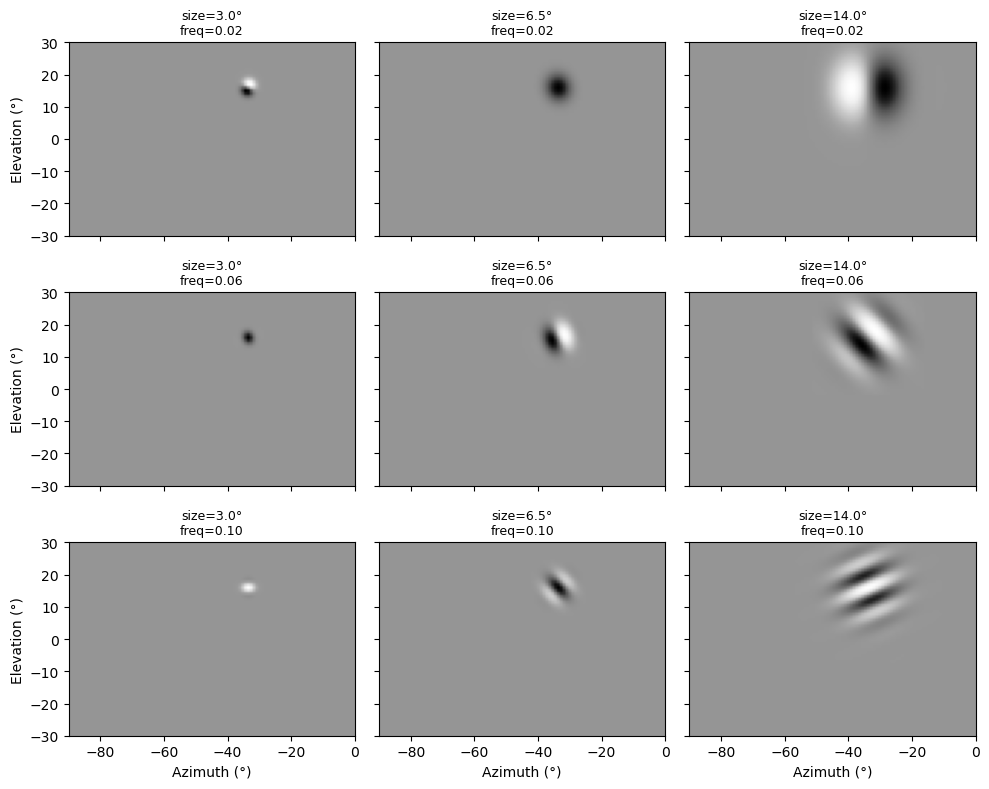

In [26]:
az_left, az_right, el_bottom, el_top = visual_coverage

# center index in library grid
i = len(xs) // 2
j = len(ys) // 2

sizeis = [0, len(sizes)//2, len(sizes)-1]
freqis = [0, len(freqs)//2, len(freqs)-1]

fig, axes = plt.subplots(
    len(freqis),
    len(sizeis),
    figsize=(10, 8),
    sharex=True,
    sharey=True
)

for row, freqi in enumerate(freqis):
    for col, sizei in enumerate(sizeis):
        anglei = np.random.randint(0, len(angles))
        phasei = np.random.randint(0, len(phases))

        filt = library[i, j, anglei, sizei, freqi, phasei, :, :]

        ax = axes[row, col]

        v = np.max(np.abs(filt))

        ax.imshow(
            filt.T,
            cmap="Greys",
            vmin=-v,
            vmax=v,
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto"
        )

        ax.set_title(
            f"size={sizes[sizei]:.1f}°\nfreq={freqs[freqi]:.2f}",
            fontsize=9
        )

        if row == len(freqis) - 1:
            ax.set_xlabel("Azimuth (°)")
        if col == 0:
            ax.set_ylabel("Elevation (°)")

plt.tight_layout()
plt.show()